# Clustering Categorical Data 

You are given much more country data. Using the same methodology as the one in the lecture, group all the countries in 2 clusters. 

<b> Already done that? Okay! </b>
    
There are other features: name and continent. 

Encode the continent one and use it in the clustering solution. Think about the difference with the previous exercise.

## Import the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

## Load the data

Load data from the csv file: <i> 'Categorical.csv'</i>.

In [2]:
data_raw = pd.read_csv('Categorical.csv')
data_raw

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,North America
1,Afghanistan,66.004734,33.835231,Asia
2,Angola,17.537368,-12.293361,Africa
3,Anguilla,-63.064989,18.223959,North America
4,Albania,20.049834,41.142450,Europe
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,Oceania
237,Yemen,47.586762,15.909280,Asia
238,South Africa,25.083901,-29.000341,Africa
239,Zambia,27.774759,-13.458242,Africa


Remove the duplicate index column from the dataset. 

## Map the data

Use the <i>'continent'</i> category for this analysis.

In [8]:
data_mapped = data_raw.copy()
data_mapped['continent'] = data_mapped['continent'].map({'North America':0 , 'Europe': 1, 'Asia': 2, 'Africa':3, 'South America':4, 'Oceania':5, 'Seven seas (open ocean)':6, 'Antarctica':7})
data_mapped

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,0
1,Afghanistan,66.004734,33.835231,2
2,Angola,17.537368,-12.293361,3
3,Anguilla,-63.064989,18.223959,0
4,Albania,20.049834,41.142450,1
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,5
237,Yemen,47.586762,15.909280,2
238,South Africa,25.083901,-29.000341,3
239,Zambia,27.774759,-13.458242,3


## Select the features

In [35]:
x = data_mapped.iloc[:, 1:4]
x

,Longitude,Latitude,continent
0,-69.982677,12.520880,0
1,66.004734,33.835231,2
2,17.537368,-12.293361,3
3,-63.064989,18.223959,0
4,20.049834,41.142450,1
...,...,...,...
236,-172.164851,-13.753243,5
237,47.586762,15.909280,2
238,25.083901,-29.000341,3
239,27.774759,-13.458242,3


## Clustering

Use 4 clusters initially.

In [41]:
kmeans  = KMeans(4)
kmeans.fit(x)
x

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Longitude,Latitude,continent
0,-69.982677,12.520880,0
1,66.004734,33.835231,2
2,17.537368,-12.293361,3
3,-63.064989,18.223959,0
4,20.049834,41.142450,1
...,...,...,...
236,-172.164851,-13.753243,5
237,47.586762,15.909280,2
238,25.083901,-29.000341,3
239,27.774759,-13.458242,3


## Clustering results

In [42]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 0, 3, 1, 0, 0, 0, 0, 1, 0, 1, 3, 2, 3, 1, 2, 0, 0, 3, 0, 3, 3,
       2, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 0, 1, 2, 3, 3,
       3, 3, 1, 1, 3, 3, 1, 1, 1, 1, 0, 0, 0, 0, 3, 1, 0, 1, 0, 1, 0, 3,
       0, 0, 3, 0, 2, 1, 0, 0, 2, 3, 0, 0, 0, 3, 3, 3, 3, 3, 0, 1, 0, 1,
       2, 1, 2, 3, 1, 0, 1, 0, 2, 0, 2, 2, 3, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       2, 2, 0, 3, 0, 2, 1, 1, 2, 0, 0, 2, 0, 3, 0, 1, 0, 2, 3, 0, 0, 0,
       2, 1, 0, 0, 0, 3, 2, 1, 2, 0, 3, 0, 2, 0, 2, 2, 3, 0, 1, 3, 3, 2,
       3, 2, 3, 2, 3, 1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1,
       2, 0, 1, 0, 1, 0, 0, 2, 3, 0, 0, 3, 3, 3, 2, 1, 3, 2, 3, 1, 0, 3,
       3, 1, 0, 3, 1, 0, 0, 0, 3, 1, 3, 0, 1, 3, 3, 2, 0, 0, 2, 1, 1, 0,
       0, 2, 3, 3, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 3, 3, 3, 3],
      dtype=int32)

## Plot the data

In [43]:
data_with_clusters = data_raw.copy()

In [44]:
data_with_clusters['Cluster']=identified_clusters
data_with_clusters

,name,Longitude,Latitude,continent,Cluster
0,Aruba,-69.982677,12.520880,North America,1
1,Afghanistan,66.004734,33.835231,Asia,0
2,Angola,17.537368,-12.293361,Africa,3
3,Anguilla,-63.064989,18.223959,North America,1
4,Albania,20.049834,41.142450,Europe,0
...,...,...,...,...,...
236,Samoa,-172.164851,-13.753243,Oceania,1
237,Yemen,47.586762,15.909280,Asia,3
238,South Africa,25.083901,-29.000341,Africa,3
239,Zambia,27.774759,-13.458242,Africa,3


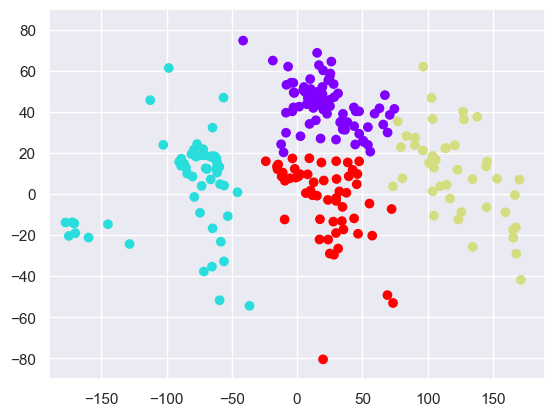

In [45]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['Cluster'], cmap='rainbow')
plt.xlim(-190,190)
plt.ylim(-90,90)
plt.show()

Since you already have all the code necessary, go back and play around with the number of clusters. Try 3, 7 and 8 and see if the results match your expectations. 

Simply go back to the beggining of the <b> Clustering </b> section and change <i> kmeans = KMeans(4) </i> to <i> kmeans = KMeans(3) </i>. Then run the remaining cells until the end.